## Carregando os modelos

In [ ]:
import joblib
import pandas as pd
import os
pd.set_option('display.max_columns', None)


output_dir = 'data'

rf_wo_smote_todos_anos = joblib.load(os.path.join(output_dir, 'rf_wo_smote_todos_anos.joblib'))
rf_wo_smote_ultimo_ano = joblib.load(os.path.join(output_dir, 'rf_wo_smote_ultimo_ano.joblib'))

df_teste = pd.read_parquet(os.path.join(output_dir, 'df_teste.parquet')).drop("NU_ANO", axis = 1)
df_treino = pd.read_parquet(os.path.join(output_dir, 'df_treino.parquet')).drop("NU_ANO", axis = 1)

X_teste = pd.read_parquet(os.path.join(output_dir, 'X_teste.parquet')).drop("NU_ANO", axis = 1)
X_treino = pd.read_parquet(os.path.join(output_dir, 'X_treino.parquet')).drop("NU_ANO", axis = 1)

y_teste = pd.read_parquet(os.path.join(output_dir, 'y_teste.parquet'))['target'] 
y_treino = pd.read_parquet(os.path.join(output_dir, 'y_treino.parquet'))['target']

# Avaliação de Equidade e Viés
Vamos avaliar diferentes métricas usando como atributo de análise **Raça**, pois

* Dado que a pessoa pertence à classe de óbito, gostaríamos que o modelo tenha a mesma chance de prever corretamente, independentemente da raça.

In [2]:
import numpy as np
import pandas as pd

codigo_raca = {1: "Branca", 2: "Preta", 4: "Parda"}

# one-hot → single column with numeric codes
raca_cols   = ['CS_RACA_1', 'CS_RACA_2', 'CS_RACA_4']
sens_test   = df_teste[raca_cols] @ np.array([1, 2, 4])
sens_train  = df_treino[raca_cols] @ np.array([1, 2, 4])

In [3]:
from fairlearn.metrics import (
    MetricFrame,
    true_positive_rate, false_positive_rate, selection_rate,
    demographic_parity_difference, equalized_odds_difference
)
from sklearn.metrics import accuracy_score, balanced_accuracy_score

def evaluate(model, X, y, sens, thresh=0.5):
    proba  = model.predict_proba(X)[:, 1]
    y_pred = (proba >= thresh).astype(int)

    # group-wise and overall metrics in one object
    mf = MetricFrame(
        metrics={
            'accuracy'        : accuracy_score,
            'balanced_acc'    : balanced_accuracy_score,
            'TPR'             : true_positive_rate,
            'FPR'             : false_positive_rate,
            'selection_rate'  : selection_rate
        },
        y_true=y,
        y_pred=y_pred,
        sensitive_features=sens
    )
    # high-level fairness gaps
    dp_diff  = demographic_parity_difference(y, y_pred, sensitive_features=sens)
    eo_diff  = equalized_odds_difference( y, y_pred, sensitive_features=sens)

    print("\n=== OVERALL ===")
    print(mf.overall)

    print("\n=== POR RAÇA ===")
    print(mf.by_group.rename(index=codigo_raca))

    print(f"\nDemographic-Parity diff : {dp_diff:.4f}")
    print(f"Equalized-Odds diff     : {eo_diff:.4f}")
    return mf, dp_diff, eo_diff


_ , dp0, eo0 = evaluate(rf_wo_smote_todos_anos, X_teste, y_teste, sens_test)


=== OVERALL ===
accuracy          0.899762
balanced_acc      0.548550
TPR               0.110577
FPR               0.013478
selection_rate    0.023095
dtype: float64

=== POR RAÇA ===
                     accuracy  balanced_acc       TPR       FPR  \
sensitive_feature_0                                               
Branca               0.905498      0.532432  0.073394  0.008531   
Preta                0.907834      0.513335  0.035088  0.008418   
Parda                0.894759      0.563335  0.144000  0.017330   

                     selection_rate  
sensitive_feature_0                  
Branca                     0.014605  
Preta                      0.010753  
Parda                      0.030608  

Demographic-Parity diff : 0.0199
Equalized-Odds diff     : 0.1089


# Aplicando reweighting para melhorar fairness

In [4]:
import pandas as pd
import numpy as np
from aif360.datasets import BinaryLabelDataset

# criando col unica para raca
sens_train_numeric = df_treino[raca_cols].values @ np.array([1, 2, 4])
df_treino['RACA'] = sens_train_numeric


features_cols = [col for col in df_treino.columns if col not in ['SITUACAO_AGRUPADA', 'RACA']]

df_train_aif = df_treino[features_cols].copy()
df_train_aif['SITUACAO_AGRUPADA'] = df_treino['SITUACAO_AGRUPADA']
df_train_aif['RACA'] = df_treino['RACA']

train_bld = BinaryLabelDataset(
    df=df_train_aif,
    label_names=['SITUACAO_AGRUPADA'],
    protected_attribute_names=['RACA'],
    favorable_label=1,
    unfavorable_label=0
)

from aif360.algorithms.preprocessing import Reweighing

rw = Reweighing(unprivileged_groups=[{'RACA': 2}], privileged_groups=[{'RACA': 1}]) # 2 (preta) como unprivileged (pois TPR estava baixo), 1 (branca) como privileged
rw.fit(train_bld)
train_rw = rw.transform(train_bld)

sample_weights = train_rw.instance_weights

X_train = df_train_aif[features_cols].values
y_train = df_train_aif['SITUACAO_AGRUPADA'].values

2025-06-10 16:36:25.942214: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-10 16:36:26.019442: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749584186.066058   51685 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749584186.078555   51685 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749584186.161407   51685 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline com scaler e random forest (sem SMOTE)
rf_fair = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestClassifier(
        class_weight='balanced',
        max_depth=10,
        min_samples_split=10,
        n_estimators=10,
        random_state=42
    ))
])

rf_fair.fit(X_treino, y_treino)


Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_split=10, n_estimators=10,
                                        random_state=42))])

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, classification_report
)

def plot_confusion_matrix_normalizada_com_metricas(y_true, y_probs, threshold=0.5):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    # Normalização por linha (classe real)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Exibição da matriz
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=["Classe 0", "Classe 1"])
    plt.figure(figsize=(6, 6))
    disp_norm.plot(cmap="Blues", values_format=".2f")
    plt.title(f'Matriz de Confusão Normalizada (Threshold = {threshold})')
    plt.grid(False)
    plt.show()
    
    # Tabela com métricas
    print(classification_report(y_true, y_pred, digits=4))

<Figure size 600x600 with 0 Axes>

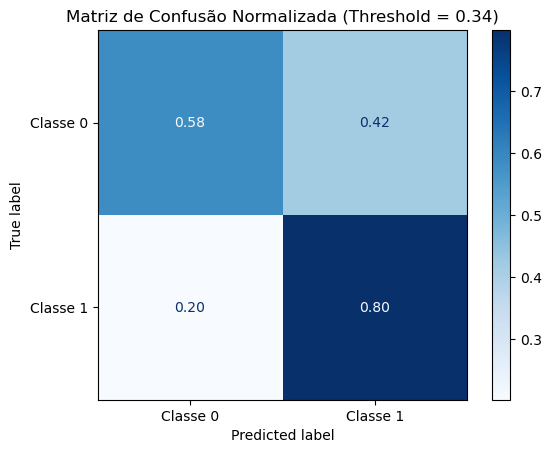

              precision    recall  f1-score   support

           0     0.9634    0.5843    0.7274      3784
           1     0.1743    0.7981    0.2861       416

    accuracy                         0.6055      4200
   macro avg     0.5688    0.6912    0.5068      4200
weighted avg     0.8852    0.6055    0.6837      4200



In [13]:
probs_teste = rf_fair.predict_proba(X_teste)[:, 1]

plot_confusion_matrix_normalizada_com_metricas(y_teste, probs_teste, threshold=0.34)

In [14]:
print("\nFairness-aware model:")
evaluate(rf_fair, X_teste, y_teste, sens_test, thresh=0.5)


Fairness-aware model:

=== OVERALL ===
accuracy          0.767619
balanced_acc      0.673125
TPR               0.555288
FPR               0.209038
selection_rate    0.243333
dtype: float64

=== POR RAÇA ===
                     accuracy  balanced_acc       TPR       FPR  \
sensitive_feature_0                                               
Branca               0.775773      0.662416  0.522936  0.198104   
Preta                0.746544      0.662857  0.561404  0.235690   
Parda                0.769392      0.680487  0.568000  0.207026   

                     selection_rate  
sensitive_feature_0                  
Branca                     0.228522  
Preta                      0.264209  
Parda                      0.244864  

Demographic-Parity diff : 0.0357
Equalized-Odds diff     : 0.0451


(<fairlearn.metrics._metric_frame.MetricFrame at 0x7ff3ab3d69c0>,
 np.float64(0.03568657260044025),
 0.045064220183486214)